# Other Data — sensor recordings

All CSVs in `Other Data - Segmented`: tri-axial acceleration for **sensor 1** and **sensor 2** (m/s²), vs time from the start of each file.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "src").is_dir() else _cwd.parent
DATA_ROOT = REPO_ROOT / "data"
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from goaltend_close_call.sensor_io import load_recording_csv

OTHER = DATA_ROOT / "Other Data - Segmented"
files = sorted(OTHER.glob("*.csv"))
print(f"Found {len(files)} trials in {OTHER.name}")
for f in files:
    print("  ", f.name)

Found 7 trials in Other Data - Segmented
   hang_on_rim_1_event_01.csv
   hang_on_rim_1_event_02.csv
   layup_2_event_01.csv
   layup_2_event_02.csv
   layup_2_event_03.csv
   layup_2_event_04.csv
   layup_2_event_05.csv


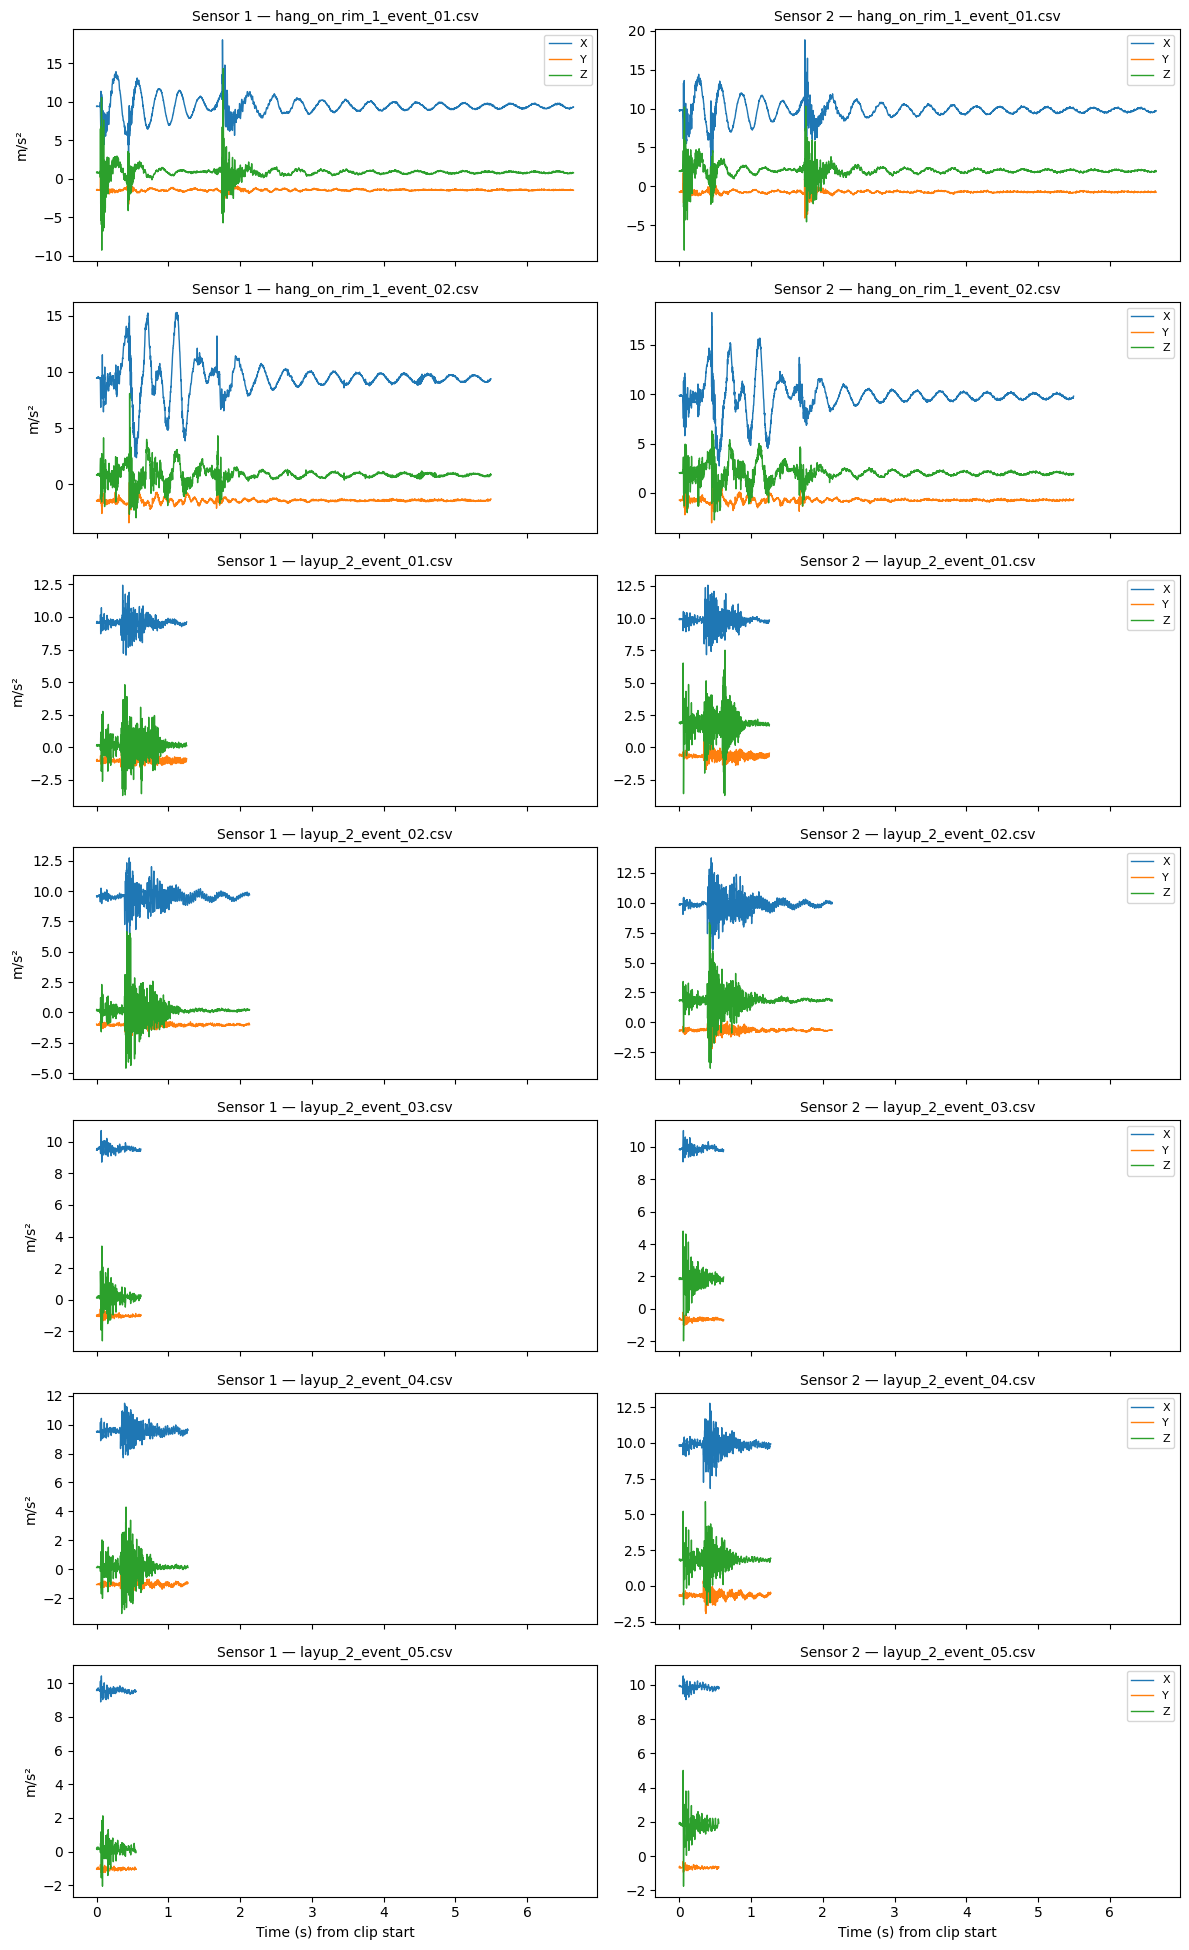

In [ ]:
# One row per trial: left = sensor 1 (X,Y,Z); right = sensor 2 (X,Y,Z)
n = len(files)
fig, axes = plt.subplots(n, 2, figsize=(12, 2.8 * n), sharex="col")
if n == 1:
    axes = np.array([axes])

colors = {"X": "#1f77b4", "Y": "#ff7f0e", "Z": "#2ca02c"}
labels = ["X", "Y", "Z"]

for i, csv_path in enumerate(files):
    t, a1, a2 = load_recording_csv(csv_path)
    t_rel = t - t[0]
    for j in range(3):
        axes[i, 0].plot(t_rel, a1[:, j], color=colors[labels[j]], label=labels[j], lw=1.0)
        axes[i, 1].plot(t_rel, a2[:, j], color=colors[labels[j]], label=labels[j], lw=1.0)
    axes[i, 0].set_ylabel("m/s²")
    axes[i, 0].set_title(f"Sensor 1 — {csv_path.name}", fontsize=10)
    axes[i, 1].set_title(f"Sensor 2 — {csv_path.name}", fontsize=10)
    axes[i, 1].legend(loc="upper right", fontsize=8)

axes[-1, 0].set_xlabel("Time (s) from clip start")
axes[-1, 1].set_xlabel("Time (s) from clip start")
axes[0, 0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

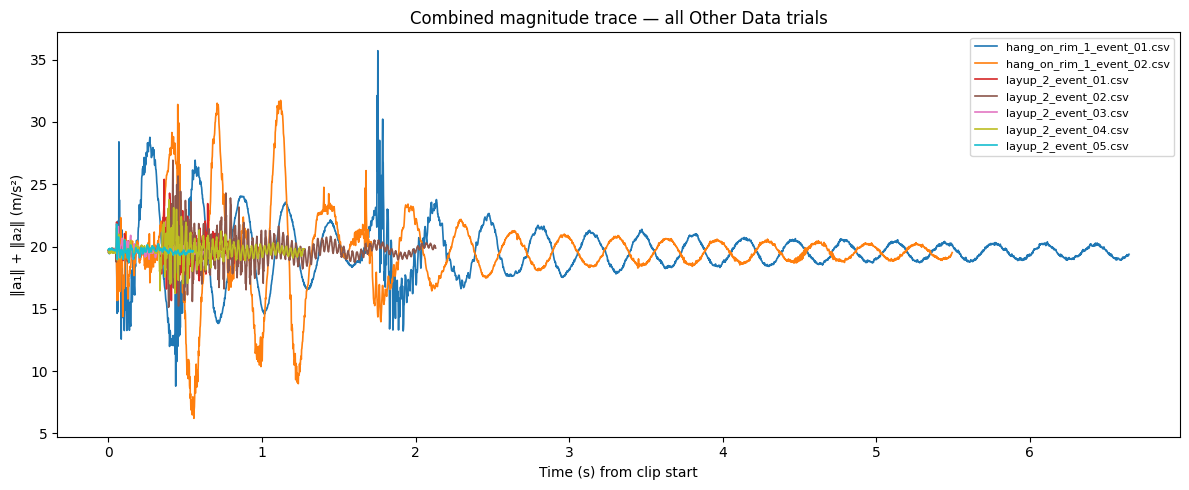

In [ ]:
# Combined magnitude (quick comparison across trials)
fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(files), 1)))
for idx, csv_path in enumerate(files):
    t, a1, a2 = load_recording_csv(csv_path)
    t_rel = t - t[0]
    mag1 = np.linalg.norm(a1, axis=1)
    mag2 = np.linalg.norm(a2, axis=1)
    ax.plot(t_rel, mag1 + mag2, color=cmap[idx], lw=1.2, label=csv_path.name)
ax.set_xlabel("Time (s) from clip start")
ax.set_ylabel("‖a₁‖ + ‖a₂‖ (m/s²)")
ax.set_title("Combined magnitude trace — all Other Data trials")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()